# Exploratory Data Analysis (EDA) example

This notebook will run through some of the basic analyses that you would typically do during EDA to get to know your data better. In this example, we will use data on the daily temperature in major global cities that can be downloaded from here: 
https://www.kaggle.com/datasets/sudalairajkumar/daily-temperature-of-major-cities

The data were originally sourced from the National Climatic Data Center, compiled by the University of Dayton. More info and data descriptions and documentation can be found here:
https://academic.udayton.edu/kissock/http/Weather/default.htm

I've added the `city_temperature.csv` file to the `data` folder in the course repository.

In [1]:
# load in the packages you will need for your analysis

import pandas as pd  # pandas is a package for data analysis and manipulation
import seaborn as sns  # seaborn is a data visualization package
import matplotlib.pyplot as plt # matplotlib is the OG python plotting library and really useful for formatting 

In [2]:
# load in the csv file with cities temperatures

# set the path to the correct directory for your particular computer
infile = 'C:/Users/jtgal/OEAS805/DATA/city_temperature.csv'

# read in the .csv file with the column separator explicitly defined
data = pd.read_csv(infile, sep = ',')

C:\Users\jtgal\AppData\Local\Temp\ipykernel_18412\4171433764.py:7: DtypeWarning: Columns (0: State) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(infile, sep = ',')


In [4]:
# convert the temperature data from F to C
# assign to a new column in the dataframe called 'AvgTemperatureC'
data['AvgTemperatureC'] = (data.AvgTemperature - 32) * 5/9
# print(data.AvgTemperature)
print(data.AvgTemperatureC)

0          17.888889
1           9.666667
2           9.333333
3           8.000000
4           8.833333
             ...    
2906322    28.000000
2906323    27.555556
2906324    29.000000
2906325    28.777778
2906326    28.666667
Name: AvgTemperatureC, Length: 2906327, dtype: float64


In [5]:
# print the information about the data in the dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2906327 entries, 0 to 2906326
Data columns (total 9 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Region           str    
 1   Country          str    
 2   State            str    
 3   City             str    
 4   Month            int64  
 5   Day              int64  
 6   Year             int64  
 7   AvgTemperature   float64
 8   AvgTemperatureC  float64
dtypes: float64(2), int64(3), str(4)
memory usage: 199.6 MB


In [6]:
# the shape of the data
# nrows, ncols

data.shape

(2906327, 9)

In [7]:
# total number of datapoints in the dataframe
# ncol * nrows

data.size

26156943

In [8]:
# gives a list of the column names in the dataframe

data.columns

Index(['Region', 'Country', 'State', 'City', 'Month', 'Day', 'Year',
       'AvgTemperature', 'AvgTemperatureC'],
      dtype='str')

In [9]:
# descriptive statistics for the numeric data in the dataframe

data.describe()

,Month,Day,Year,AvgTemperature,AvgTemperatureC
count,2.906327e+06,2.906327e+06,2.906327e+06,2.906327e+06,2.906327e+06
mean,6.469163e+00,1.571682e+01,2.006624e+03,5.600492e+01,1.333607e+01
std,3.456489e+00,8.800534e+00,2.338226e+01,3.212359e+01,1.784644e+01
min,1.000000e+00,0.000000e+00,2.000000e+02,-9.900000e+01,-7.277778e+01
25%,3.000000e+00,8.000000e+00,2.001000e+03,4.580000e+01,7.666667e+00
50%,6.000000e+00,1.600000e+01,2.007000e+03,6.250000e+01,1.694444e+01
75%,9.000000e+00,2.300000e+01,2.013000e+03,7.550000e+01,2.416667e+01
max,1.200000e+01,3.100000e+01,2.020000e+03,1.100000e+02,4.333333e+01


In [10]:
# correlations between the different numeric data columns in the dataframe

data.corr(numeric_only = True)

,Month,Day,Year,AvgTemperature,AvgTemperatureC
Month,1.000000,0.011209,-0.026898,0.075037,0.075037
Day,0.011209,1.000000,-0.002213,0.000100,0.000100
Year,-0.026898,-0.002213,1.000000,0.087245,0.087245
AvgTemperature,0.075037,0.000100,0.087245,1.000000,1.000000
AvgTemperatureC,0.075037,0.000100,0.087245,1.000000,1.000000


In [13]:
# get a list of the unique values found in the 'City' column of the dataframe
data['City'].unique()

# assign the list of unique values of 'City' to a new variable called 'cities'
cities = data['City'].unique()
print(cities)

<StringArray>
[             'Algiers',            'Bujumbura',              'Cotonou',
               'Bangui',          'Brazzaville',                'Cairo',
          'Addis Ababa',           'Libreville',               'Banjul',
              'Conakry',
 ...
              'Seattle',              'Spokane',               'Yakima',
               'Elkins',            'Green Bay',              'Madison',
            'Milwaukee',               'Casper',             'Cheyenne',
 'San Juan Puerto Rico']
Length: 321, dtype: str


In [14]:
print(cities[99:112])

<StringArray>
[ 'Bucharest',     'Moscow',    'Yerevan',   'Pristina', 'Bratislava',
  'Barcelona',     'Bilbao',     'Madrid',  'Stockholm',       'Bern',
     'Geneva',     'Zurich',       'Kiev']
Length: 13, dtype: str


In [15]:
# Group the data by a particular column
# In this case, the data is grouped by country, and I am only interested in the 'City' column

data.groupby('Country')['City'].unique()

Country
Albania                                             [Tirana]
Algeria                                            [Algiers]
Argentina                                     [Buenos Aires]
Australia     [Brisbane, Canberra, Melbourne, Perth, Sydney]
Austria                                             [Vienna]
                                   ...                      
Uzbekistan                                        [Tashkent]
Venezuela                                          [Caracas]
Vietnam                                              [Hanoi]
Yugoslavia                                        [Belgrade]
Zambia                                              [Lusaka]
Name: City, Length: 125, dtype: object

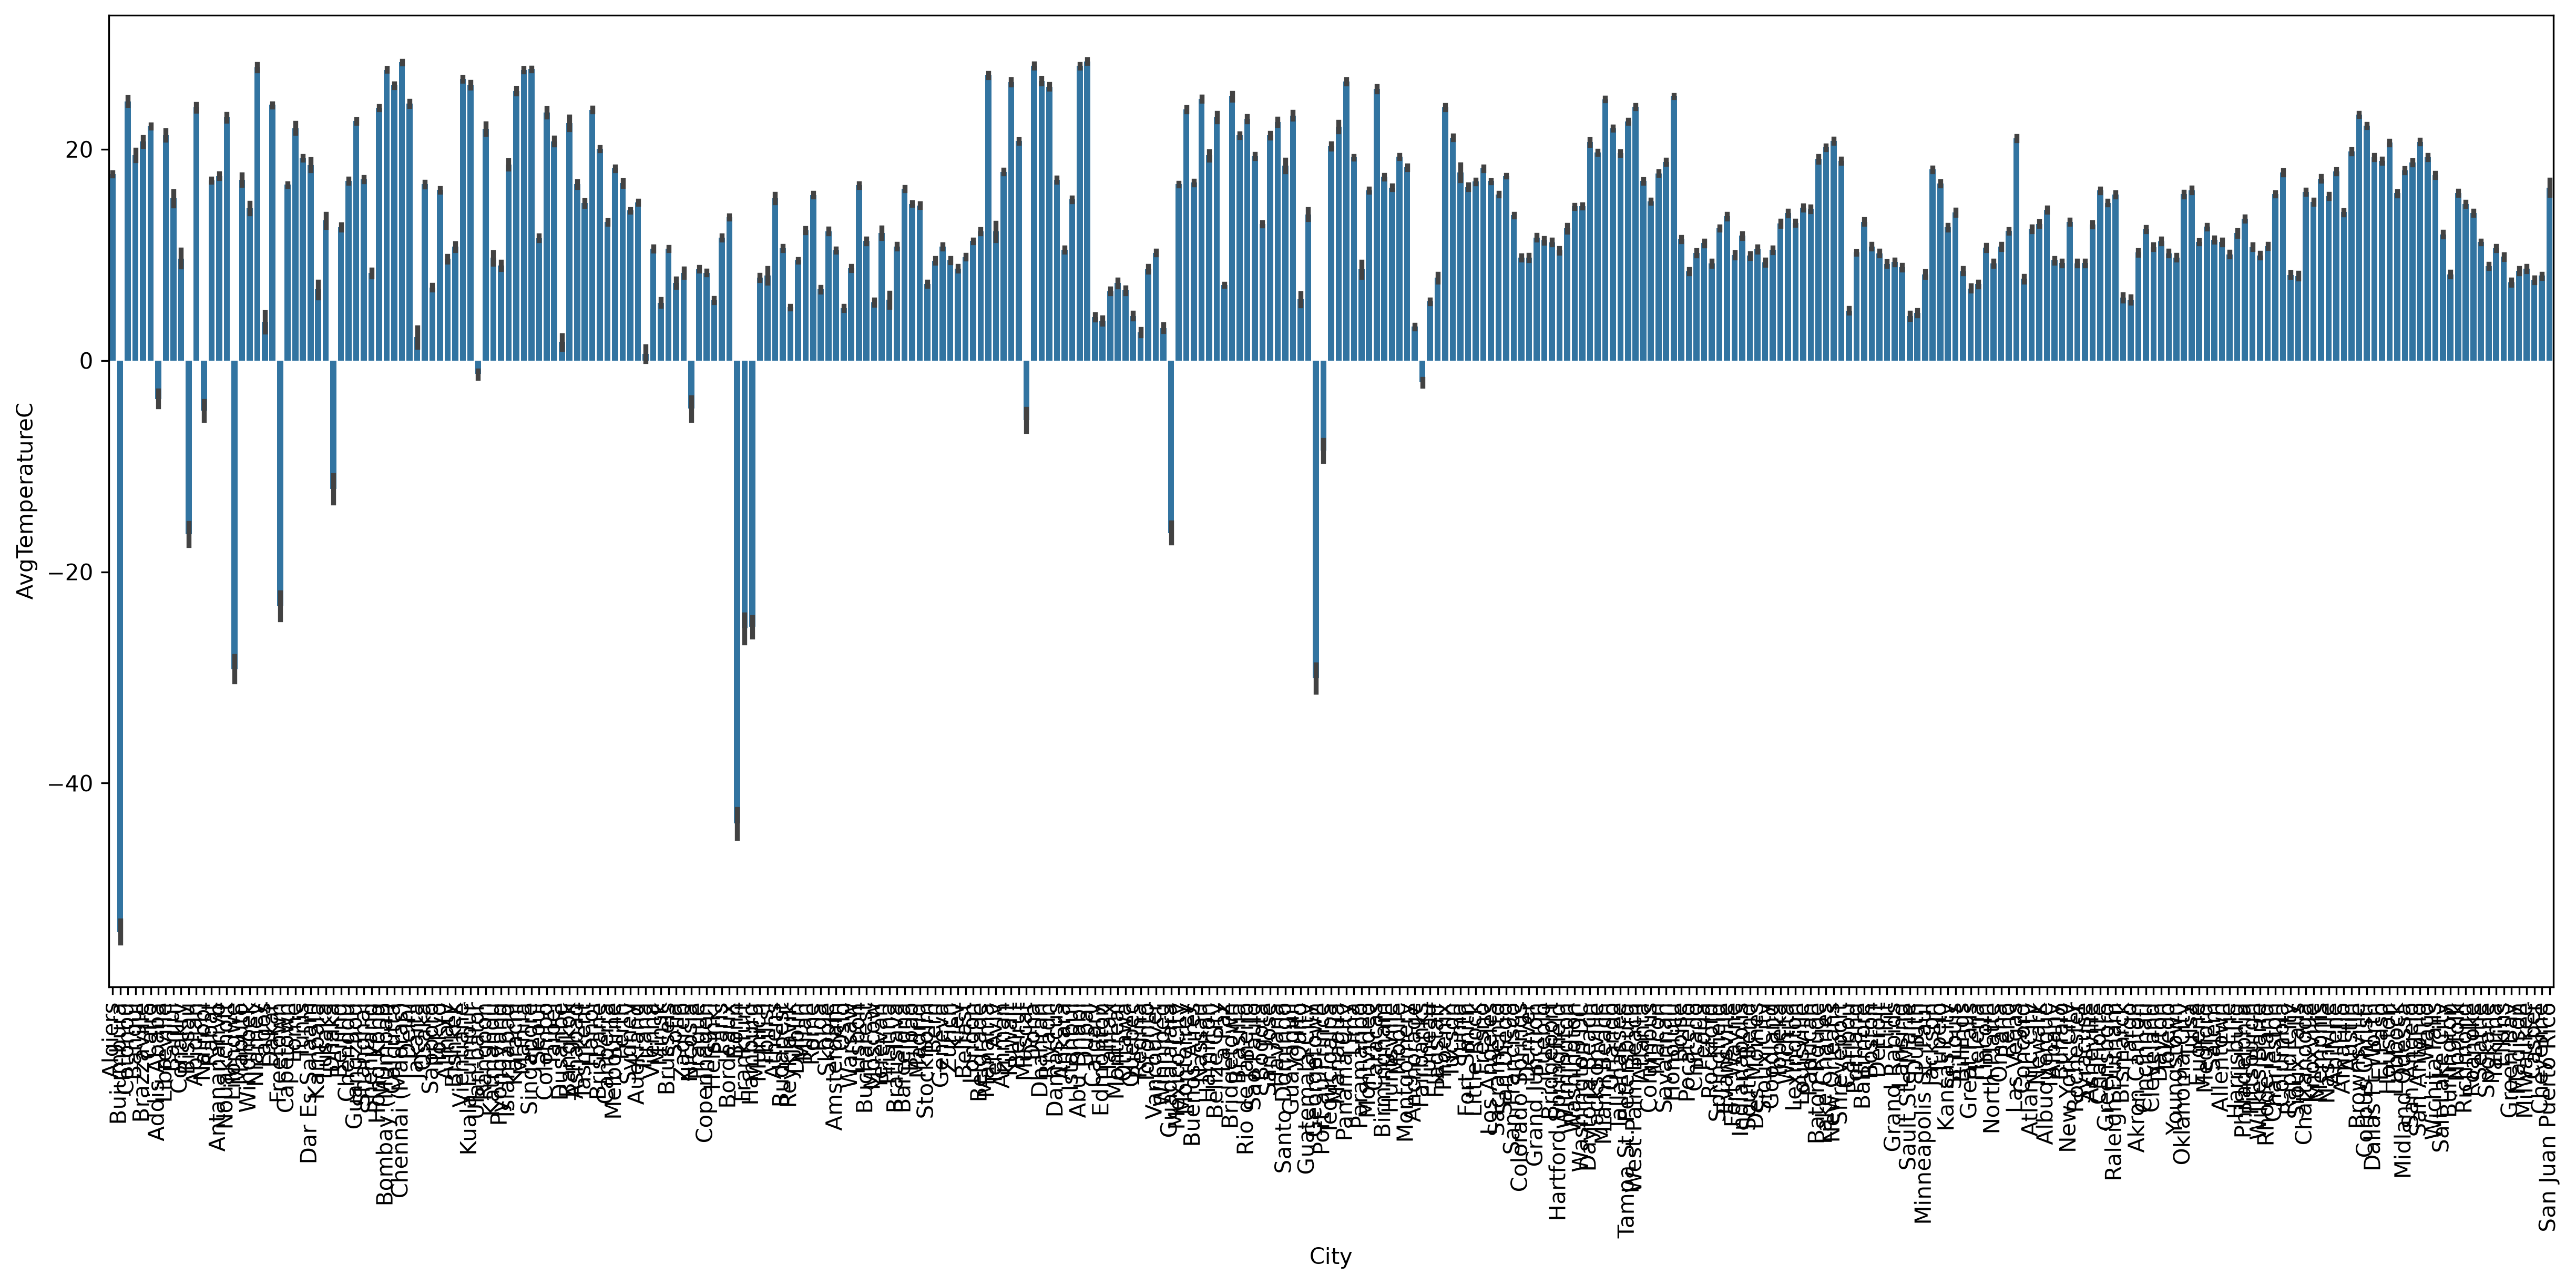

In [16]:
fig, ax = plt.subplots(1, figsize = (20,8), dpi = 300)

sns.barplot(data = data, x = 'City', y = 'AvgTemperatureC')
ax.tick_params(axis='x', rotation=90)

In [17]:
data.Year.unique()

array([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020,  201,  200])

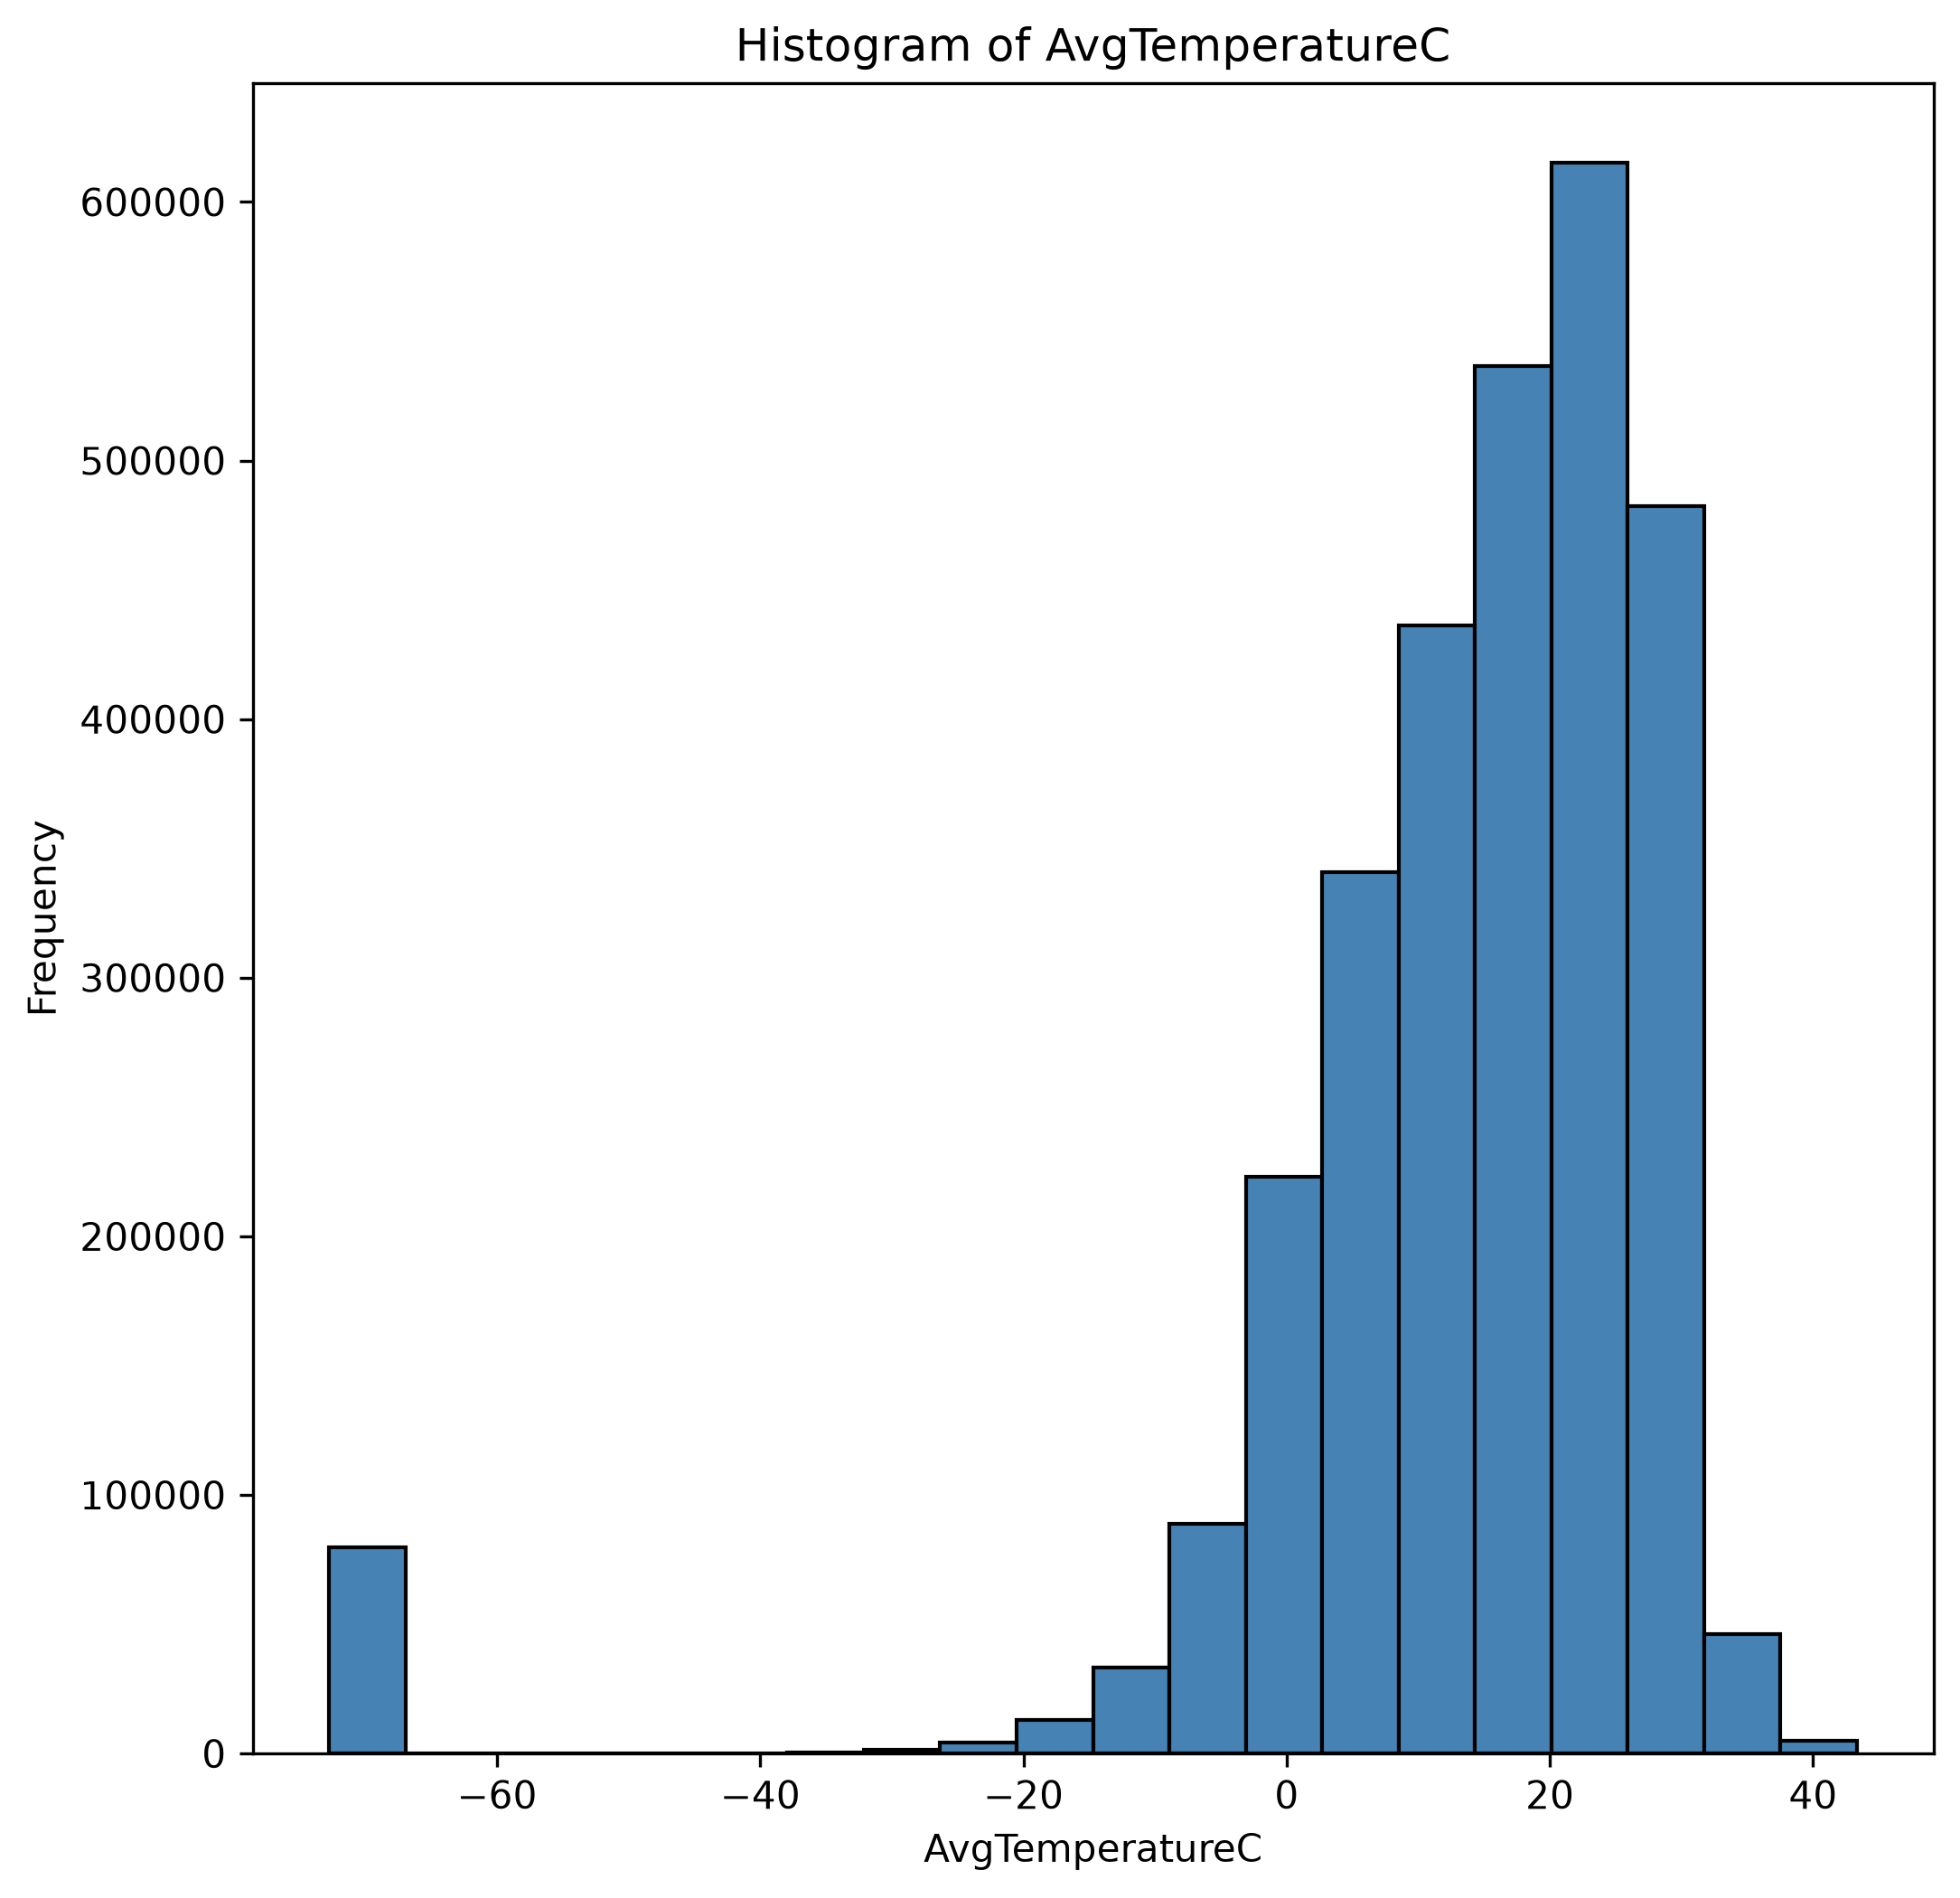

In [18]:
# histograms are the best, fastest data "check" for single variables
# in matplotlib, this is plt.hist

fig, ax = plt.subplots(1, figsize = (8,8), dpi = 300)
plt.hist(data["AvgTemperatureC"].dropna(), bins=20, color="steelblue", edgecolor="black")
plt.title("Histogram of AvgTemperatureC")
plt.xlabel("AvgTemperatureC")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Find where Country equals Costa Rica, and assign that to a new variable called 'cr'
cr = data[data['Country'] == 'Costa Rica']
cr.info

<bound method DataFrame.info of                                     Region     Country State      City  Month  \
1319838  South/Central America & Carribean  Costa Rica   NaN  San Jose      1   
1319839  South/Central America & Carribean  Costa Rica   NaN  San Jose      1   
1319840  South/Central America & Carribean  Costa Rica   NaN  San Jose      1   
1319841  South/Central America & Carribean  Costa Rica   NaN  San Jose      1   
1319842  South/Central America & Carribean  Costa Rica   NaN  San Jose      1   
...                                    ...         ...   ...       ...    ...   
1329099  South/Central America & Carribean  Costa Rica   NaN  San Jose      5   
1329100  South/Central America & Carribean  Costa Rica   NaN  San Jose      5   
1329101  South/Central America & Carribean  Costa Rica   NaN  San Jose      5   
1329102  South/Central America & Carribean  Costa Rica   NaN  San Jose      5   
1329103  South/Central America & Carribean  Costa Rica   NaN  San Jose      5

<Axes: xlabel='Year', ylabel='AvgTemperatureC'>

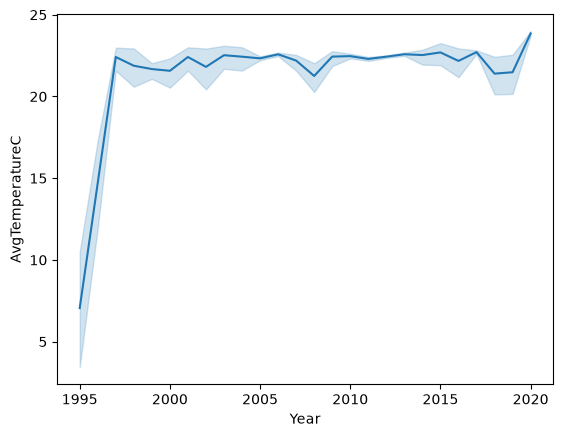

In [ ]:
# Make a line plot of the average temperature in Costa Rica over time
sns.lineplot(x = 'Year', y = 'AvgTemperatureC', data = cr)

In [ ]:
# Find where Country equals Germany, and assign that to a new variable called 'gr'
gr = data[data['Country'] == 'Germany']
gr.info

<bound method DataFrame.info of         Region  Country State    City  Month  Day  Year  AvgTemperature  \
730952  Europe  Germany   NaN    Bonn      1    1  1995           -99.0   
730953  Europe  Germany   NaN    Bonn      1    2  1995            32.6   
730954  Europe  Germany   NaN    Bonn      1    3  1995            31.8   
730955  Europe  Germany   NaN    Bonn      1    4  1995           -99.0   
730956  Europe  Germany   NaN    Bonn      1    5  1995            19.1   
...        ...      ...   ...     ...    ...  ...   ...             ...   
755729  Europe  Germany   NaN  Munich      5    9  2020            64.5   
755730  Europe  Germany   NaN  Munich      5   10  2020            61.2   
755731  Europe  Germany   NaN  Munich      5   11  2020            52.5   
755732  Europe  Germany   NaN  Munich      5   12  2020            43.0   
755733  Europe  Germany   NaN  Munich      5   13  2020            42.4   

        AvgTemperatureC  
730952       -72.777778  
730953         

<Axes: xlabel='City', ylabel='AvgTemperatureC'>

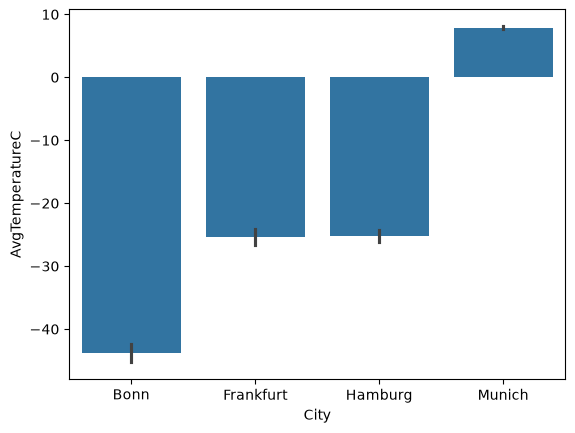

In [ ]:
# Make a bar plot of the average temperature in Germany over time
sns.barplot(data = gr, x = 'City', y = 'AvgTemperatureC')